In [1]:
import os

os.getcwd()
os.chdir('c:/Users/demki/Desktop/Python/Data/Git files/speaker+accent+recognition')

In [2]:
import pandas as pd 
df = pd.read_csv("accent-mfcc-data-1.csv")
df.head()

,language,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12
0,ES,7.071476,-6.512900,7.650800,11.150783,-7.657312,12.484021,-11.709772,3.426596,1.462715,-2.812753,0.866538,-5.244274
1,ES,10.982967,-5.157445,3.952060,11.529381,-7.638047,12.136098,-12.036247,3.491943,0.595441,-4.508811,2.332147,-6.221857
2,ES,7.827108,-5.477472,7.816257,9.187592,-7.172511,11.715299,-13.847214,4.574075,-1.687559,-7.204041,-0.011847,-6.463144
3,ES,6.744083,-5.688920,6.546789,9.000183,-6.924963,11.710766,-12.374388,6.169879,-0.544747,-6.019237,1.358559,-6.356441
4,ES,5.836843,-5.326557,7.472265,8.847440,-6.773244,12.677218,-12.315061,4.416344,0.193500,-3.644812,2.151239,-6.816310


In [3]:
print(df.shape)
print(df.info())
print(df.describe())

(329, 13)
<class 'pandas.DataFrame'>
RangeIndex: 329 entries, 0 to 328
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   language  329 non-null    str    
 1   X1        329 non-null    float64
 2   X2        329 non-null    float64
 3   X3        329 non-null    float64
 4   X4        329 non-null    float64
 5   X5        329 non-null    float64
 6   X6        329 non-null    float64
 7   X7        329 non-null    float64
 8   X8        329 non-null    float64
 9   X9        329 non-null    float64
 10  X10       329 non-null    float64
 11  X11       329 non-null    float64
 12  X12       329 non-null    float64
dtypes: float64(12), str(1)
memory usage: 34.2 KB
None
               X1          X2          X3          X4          X5          X6  \
count  329.000000  329.000000  329.000000  329.000000  329.000000  329.000000   
mean     5.645227   -4.270814    2.635319    7.200207   -5.648733    9.810236   
std      5.10

In [4]:
df.isna().sum()

language    0
X1          0
X2          0
X3          0
X4          0
X5          0
X6          0
X7          0
X8          0
X9          0
X10         0
X11         0
X12         0
dtype: int64

In [5]:
df['language'].value_counts()

language
US    165
UK     45
FR     30
GE     30
IT     30
ES     29
Name: count, dtype: int64

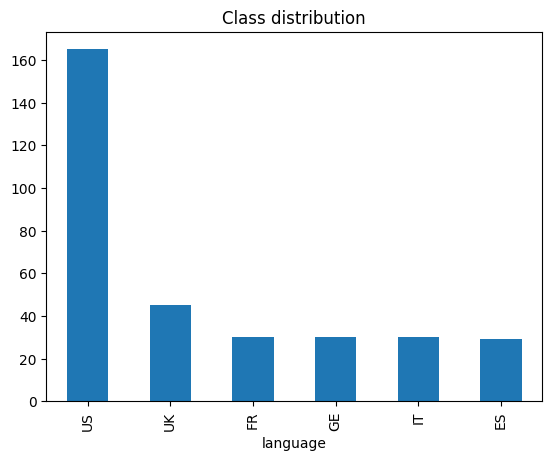

In [6]:
import numpy as np 
import matplotlib.pyplot as plt 
df['language'].value_counts().plot(kind="bar")
plt.title("Class distribution")
plt.show()

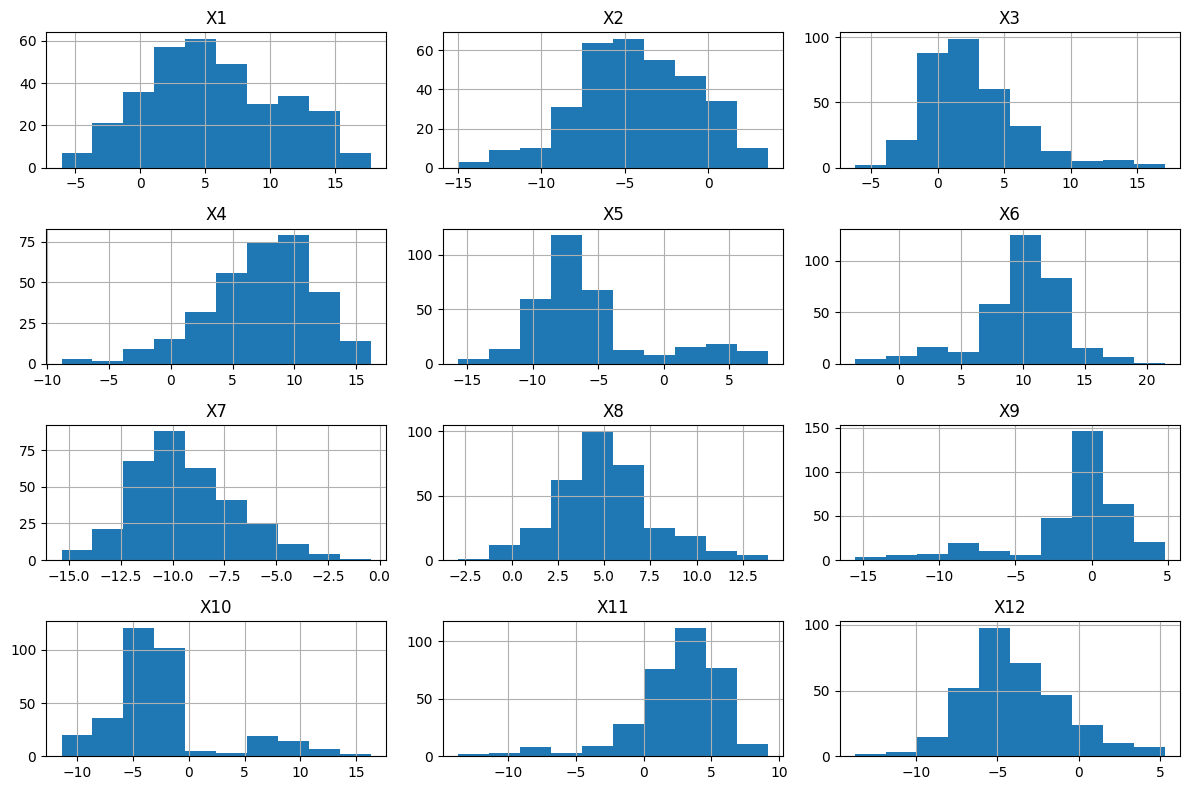

In [7]:
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()


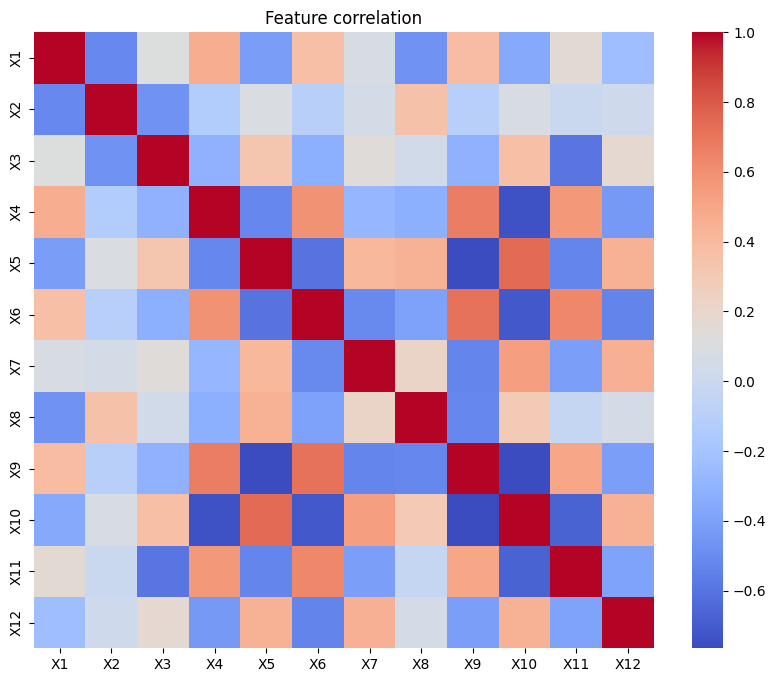

In [8]:
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(df.drop("language", axis=1).corr(), cmap="coolwarm")
plt.title("Feature correlation")
plt.show()


In [9]:
X = df.drop("language", axis=1)
y = df["language"]

In [10]:
from sklearn.model_selection import train_test_split, GridSearchCV
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [13]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
log_preds = log_model.predict(X_test)
print("Accuracy: ", accuracy_score(y_test, log_preds) )

Accuracy:  0.7878787878787878


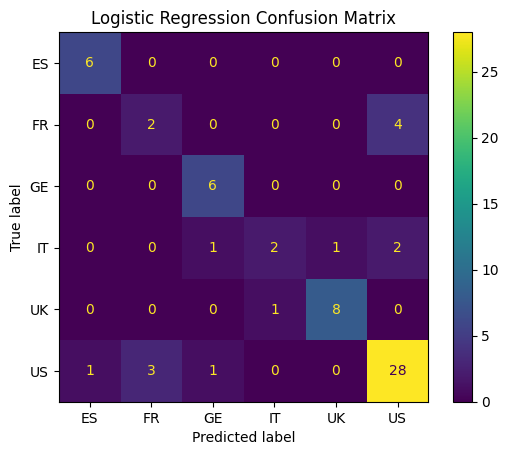

In [14]:
ConfusionMatrixDisplay.from_estimator(log_model, X_test, y_test) 
plt.title("Logistic Regression Confusion Matrix") 
plt.show()

In [18]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
print("Accuracy: ",accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

      


Accuracy:  0.8484848484848485
              precision    recall  f1-score   support

          ES       0.86      1.00      0.92         6
          FR       1.00      0.33      0.50         6
          GE       1.00      1.00      1.00         6
          IT       1.00      0.50      0.67         6
          UK       1.00      0.78      0.88         9
          US       0.78      0.97      0.86        33

    accuracy                           0.85        66
   macro avg       0.94      0.76      0.80        66
weighted avg       0.88      0.85      0.83        66



Accuracy: 0.7878787878787878
              precision    recall  f1-score   support

          ES       0.83      0.83      0.83         6
          FR       1.00      0.33      0.50         6
          GE       0.83      0.83      0.83         6
          IT       0.38      0.50      0.43         6
          UK       1.00      0.67      0.80         9
          US       0.82      0.94      0.87        33

    accuracy                           0.79        66
   macro avg       0.81      0.68      0.71        66
weighted avg       0.82      0.79      0.78        66



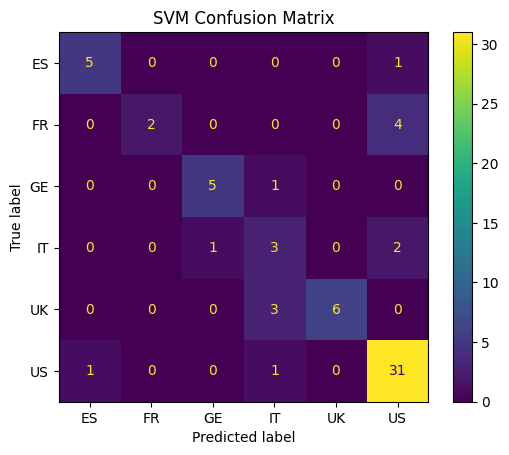

In [19]:
from sklearn.svm import SVC
svm = SVC(kernel="rbf")
svm.fit(X_train, y_train) 
svm_preds = svm.predict(X_test)
print("Accuracy:", accuracy_score(y_test, svm_preds)) 
print(classification_report(y_test, svm_preds))
ConfusionMatrixDisplay.from_estimator(svm, X_test, y_test) 
plt.title("SVM Confusion Matrix") 
plt.show()

In [21]:
param_grid = { "n_estimators": [200, 300, 400], "max_depth": [None, 5, 10], "min_samples_split": [2, 5] }
grid = GridSearchCV( RandomForestClassifier(random_state=42), param_grid, cv=5, n_jobs=-1 )
grid.fit(X_train, y_train)
print("Best parameters:", grid.best_params_) 
best_rf = grid.best_estimator_ 
best_preds = best_rf.predict(X_test)
print("Tuned RF Accuracy:", accuracy_score(y_test, best_preds))
print(classification_report(y_test, best_preds))

Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Tuned RF Accuracy: 0.8484848484848485
              precision    recall  f1-score   support

          ES       0.86      1.00      0.92         6
          FR       1.00      0.33      0.50         6
          GE       1.00      1.00      1.00         6
          IT       1.00      0.50      0.67         6
          UK       1.00      0.78      0.88         9
          US       0.78      0.97      0.86        33

    accuracy                           0.85        66
   macro avg       0.94      0.76      0.80        66
weighted avg       0.88      0.85      0.83        66

